In [1]:
import corner
import emcee
import matplotlib.pyplot as plt

/Users/alessandroperrone/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [ ]:
import numpy as np
import torch
from matplotlib.patches import Patch
from sbi import utils as sbi_utils
from sbi.inference import NPE, simulate_for_sbi
from sbi.neural_nets import posterior_nn

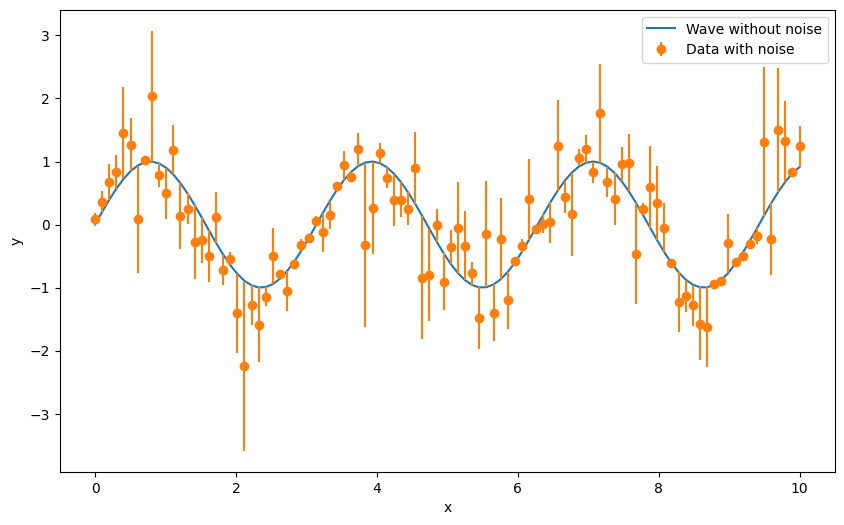

In [4]:
def simulate_wave(params):
    """Simulate a wave and add noise."""
    x = np.linspace(0, 10, 100)
    noise = 0.5 * np.random.normal(0, 1, size=x.shape)
    amplitude = params[0]
    omega = params[1]
    wave = amplitude * np.sin(omega * x) + noise
    return x, wave, noise

params = (1.0, 2.0)

points, w, n = simulate_wave(params)
plt.figure(figsize=(10, 6))
plt.plot(points, params[0]*np.sin(params[1] * points), label='Wave without noise')
plt.errorbar(points, w, yerr = np.sqrt(n*n), fmt='o', label='Data with noise')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

now the goal is to learn the true values of amplitude and frequency given noisy data points

In [28]:
"""
Wave Parameter Recovery with SBI — Class Implementation
===================================================================

Unified interface for recovering wave parameters using SBI/NPE.

NOISE MODEL: Sine wave with noise on datapoints:
  wave_obs = A * sin(ω * x) + ε,  ε ~ N(0, σ²)

Usage:
    study = WaveSBI(
        n_points=50,
        n_simulations=10000,
        noise_std=0.8
    )
    study.run_all()
"""

import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import Patch
from sbi import utils as sbi_utils
from sbi.inference import NPE, simulate_for_sbi


class WaveSBI:
    """
    Unified interface for comparing MCMC and SBI/NPE on wave parameter recovery.
    
    Noise Model: wave_obs = A * sin(ω * x) + ε  (wave noise, constant measurement error)
    
    Attributes:
        n_points : int
            Number of measurement positions
        n_simulations : int
            Number of simulations for SBI training
        noise_std : float
            Standard deviation of wave measurement noise
        true_A : float
            True amplitude (units)
        true_omega : float
            True angular frequency (rad/s)
    """
    
    def __init__(self, n_points=50, n_simulations=10000, noise_std=0.8,
                 true_A=1.0, true_omega=2.0, seed=42, n_posterior=10000, nbins=10,
                 flow =  posterior_nn(
        model="nsf",
        hidden_features=128,
        num_transforms=10,
        num_bins=16,
        tail_bound=3.0,
    ),

                 ):
        """
        Initialize the Wave Parameter Recovery study.
        
        Parameters:
        -----------
        n_points : int, default=50
            Number of measurement points (spatial positions)
        n_simulations : int, default=10000
            Number of simulations to generate for SBI training
        noise_std : float, default=0.8
            Standard deviation of wave measurement noise
        true_A : float, default=1.0
            True amplitude (units)
        true_omega : float, default=2.0
            True angular frequency (rad/s)
        seed : int, default=42
            Random seed for reproducibility
        n_posterior : int, default=5000
            Number of posterior samples to draw from SBI
        nbins : int, default=10
            Number of bins in which we divide the data
        flow: sbi.neural_nets.posterior_nn, the type normalizing flow to use.
        """
        # Store parameters
        self.n_points = n_points
        self.n_simulations = n_simulations
        self.noise_std = noise_std
        self.true_A = true_A
        self.true_omega = true_omega
        self.seed = seed
        self.n_posterior = n_posterior
        self.nbins = nbins 
        self.flow = flow
    
        # Initialize random seeds
        self.rng = np.random.default_rng(seed)
        torch.manual_seed(seed)
        
        # Create measurement positions and observed data
        self.x_positions = np.linspace(-2.0, 2.0, n_points)
        self.wave_observed = self._generate_observed_data()

        self.wave_observed_binned = self._bin_data(self.wave_observed, nbins)
        self.x_bins = self._bin_data(self.x_positions, nbins)   # bin positions too for plotting      
        
        # Results storage
        self.mcmc_samples = None
        self.sbi_samples_np = None
        self.A_mcmc = None
        self.omega_mcmc = None
        self.A_sbi = None
        self.omega_sbi = None
        self.posterior = None
        
    def _generate_observed_data(self):
        """
        Generate synthetic noisy wave measurements.
        Model: wave_obs = A * sin(ω * x) + ε,  ε ~ N(0,1)
        """
        wave_clean = self.true_A * np.sin(self.true_omega * self.x_positions)
        self.wave_noise = self.rng.normal(0, self.noise_std, self.n_points)
        return wave_clean + self.wave_noise
    
    def _bin_data(self, y: np.ndarray, n_bins: int) -> np.ndarray:
        """
        Bin y into n_bins groups and return bin means.
        Uncertainty propagation is implicit: binning n points each with std σ
        gives a bin mean with std σ/√n — the simulator handles this automatically.
        """
        # Trim to make length divisible by n_bins
        n_trim = (len(y) // n_bins) * n_bins
        return y[:n_trim].reshape(n_bins, -1).mean(axis=1)   # shape: (n_bins,)

    def run_sbi(self, verbose=True):
        """
        Run SBI/NPE training and sample from posterior.
        
        Parameters:
        -----------
        verbose : bool, default=True
            Print progress and results
        """
        if verbose:
            print("=" * 60)
            print("SBI — Neural Posterior Estimation (NPE)")
            print("=" * 60)
        
        # Step 1: Define prior
        prior = sbi_utils.BoxUniform(
            low=torch.tensor([0.0, 0.0]),
            high=torch.tensor([5.0, 20.0])
        )
        
        # Step 2: Define simulator with WAVE NOISE model
        x_torch = torch.tensor(self.x_positions, dtype=torch.float32)
        
        def wave_simulator(theta):
            """
            Simulator for wave measurements.
            Model: y = A*sin(ω*x) + σ*ε,  ε ~ N(0,1)
            """
            if theta.dim() == 1:
                theta = theta.unsqueeze(0)
            
            A = theta[:, 0]
            omega = theta[:, 1]
            
            # wave_clean: (batch, n_points)
            # noise: (batch, n_points)
            # wave_obs: (batch, n_points)
            wave_clean = A.unsqueeze(1) * torch.sin(omega.unsqueeze(1) * x_torch.unsqueeze(0))
            noise = self.noise_std * torch.randn_like(wave_clean)
            wave_obs = wave_clean + noise


            # Bin each simulation the same way as the real data
            n_trim   = (self.n_points // self.nbins) * self.nbins
            wave_cut = wave_obs[:, :n_trim]          # (batch, n_trim)
            wave_bin = wave_cut.reshape(theta.shape[0], self.nbins, -1).mean(dim=2) # (batch, n_bins, pts_per_bin)
            
            return wave_bin
        
        # Step 3: Generate simulations
        if verbose:
            print(f"\nGenerating {self.n_simulations} simulations …")
        
        theta_sim, x_sim = simulate_for_sbi(
            simulator = wave_simulator,
            proposal=prior,
            num_simulations=self.n_simulations,
        )
        if verbose:
            print(f"Simulated theta shape : {theta_sim.shape}")
            print(f"Simulated x shape     : {x_sim.shape}")
        
        # Step 4: Train neural density estimator
        if verbose:
            print("\nTraining NPE …")
        
        inference = NPE(prior=prior, density_estimator=self.flow)
        density_estimator = inference.append_simulations(theta_sim, x_sim).train(show_train_summary=verbose)
        '''
        density_estimator = inference.train(
            training_batch_size=256,
            max_num_epochs=200,
            show_train_summary=verbose,
        )
        '''
        # Step 5: Build posterior and sample
        self.posterior = inference.build_posterior(density_estimator)
        x_obs_torch = torch.tensor(self.wave_observed_binned, dtype=torch.float32) # using binned now!
        
        sbi_samples = self.posterior.sample(
            (self.n_posterior,),
            x=x_obs_torch,
        )
        self.sbi_samples_np = sbi_samples.numpy()
        self.A_sbi = np.median(self.sbi_samples_np[:, 0])
        self.omega_sbi = np.median(self.sbi_samples_np[:, 1])
        
        if verbose:
            print(f"\nSBI/NPE: A = {self.A_sbi:.3f},  omega = {self.omega_sbi:.3f}")
            print(f"         (true: {self.true_A}, {self.true_omega})\n")
    
    def plot_comparison(self, figsize=(15, 4)):
        print("\nPlotting …")
        x_line = np.linspace(self.x_positions.min(), self.x_positions.max(), 200)

        # ── 3-panel figure: predictive | P(A|data) | P(ω|data) ──────────────
        fig, axes = plt.subplots(1, 3, figsize=figsize)   # 1 row, not 2
        fig.suptitle("SBI (NPE) — Wave Parameter Recovery", fontsize=14)

        # (a) Posterior predictive
        ax = axes[0]
        pp_idx = self.rng.integers(self.n_posterior, size=200)
        for s in self.sbi_samples_np[pp_idx]:
            ax.plot(x_line, s[0] * np.sin(s[1] * x_line),   # FIX 1: np.sin, use both params
                    color="darkblue", alpha=0.05, lw=1)
        ax.errorbar(self.x_positions, self.wave_observed, yerr=np.abs(self.wave_noise), fmt = 'o', 
                color="tomato", zorder=5, markersize=2,linestyle = 'none', label="Data")
        ax.plot(x_line, self.true_A * np.sin(self.true_omega * x_line),   # FIX 2: np.sin
                "k--", lw=2, label=f"True A={self.true_A}, ω={self.true_omega}")
        ax.plot(x_line, self.A_sbi * np.sin(self.omega_sbi * x_line),
                "darkorange", lw=2, label=f"SBI  A={self.A_sbi:.2f}, ω={self.omega_sbi:.2f}")
        ax.set(xlabel="Position (m)", ylabel="Amplitude", title="Posterior predictive")
        ax.legend(fontsize=8)

        # (b) Marginal posterior for A
        ax = axes[1]
        ax.hist(self.sbi_samples_np[:, 0], bins=40, density=True,
                color="darkorange", alpha=0.7)
        ax.axvline(self.true_A, color="black", lw=2, ls="--", label=f"True A={self.true_A}")
        ax.axvline(self.A_sbi,  color="tomato", lw=2,          label=f"Median={self.A_sbi:.2f}")
        lo, hi = np.percentile(self.sbi_samples_np[:, 0], [16, 84])
        ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
        ax.set(xlabel="A", ylabel="Density", title="P(A | data)")
        ax.legend(fontsize=8)

        # (c) Marginal posterior for ω
        ax = axes[2]
        ax.hist(self.sbi_samples_np[:, 1], bins=40, density=True,
                color="darkorange", alpha=0.7)
        ax.axvline(self.true_omega, color="black", lw=2, ls="--", label=f"True ω={self.true_omega}")
        ax.axvline(self.omega_sbi,  color="tomato", lw=2,          label=f"Median={self.omega_sbi:.2f}")
        lo, hi = np.percentile(self.sbi_samples_np[:, 1], [16, 84])
        ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
        ax.set(xlabel="ω (rad/s)", ylabel="Density", title="P(ω | data)")
        ax.legend(fontsize=8)

        plt.tight_layout()
        plt.savefig("sbi_wave_results.png", dpi=150, bbox_inches="tight")
        plt.show()

        # ── Corner plot: joint posterior P(A, ω | data) ──────────────────────
        fig2 = corner.corner(
            self.sbi_samples_np,
            labels=["A", "ω (rad/s)"],
            truths=[self.true_A, self.true_omega],
            truth_color="black",
            color="darkorange",
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True,
        )
        fig2.suptitle("Joint posterior  P(A, ω | data)", y=1.02, fontsize=13)
        plt.savefig("sbi_wave_corner.png", dpi=150, bbox_inches="tight")
        plt.show()

        print("\n── Summary ─────────────────────────────────────────────")
        print(f"{'':10} {'A':>8} {'ω':>8}")
        print(f"{'True':10} {self.true_A:>8.3f} {self.true_omega:>8.3f}")
        print(f"{'SBI/NPE':10} {self.A_sbi:>8.3f} {self.omega_sbi:>8.3f}")


    def run_all(self, verbose=True):
        self.run_sbi(verbose=verbose)
        self.plot_comparison()          # FIX 4: removed non-existent print_summary()


#study = WaveSBI(n_points=300, n_simulations=10000, noise_std=0.3, true_A=1.0, true_omega=10.0, seed=42, n_posterior=10000)
#study.run_all()

okay let's try now to see how the SBI performs on binned data

100%|██████████| 10000/10000 [00:00<00:00, 63664.75it/s]


 Neural network successfully converged after 168 epochs.

Drawing 10000 posterior samples: 100%|██████████| 10000/10000 [00:00<00:00, 367122.75it/s]



Plotting …


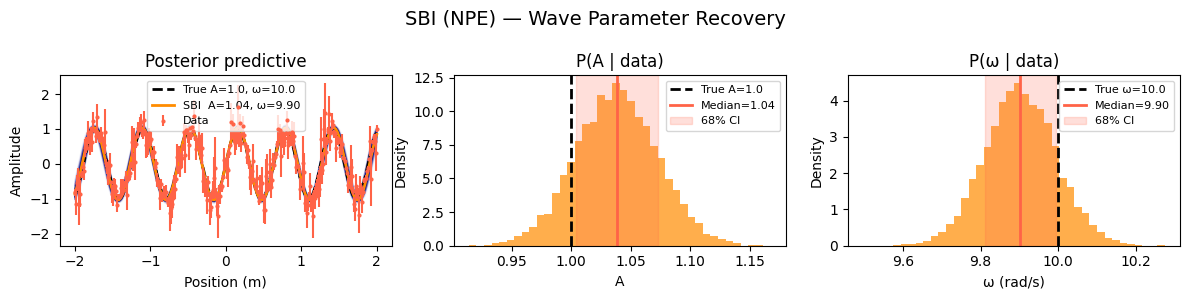

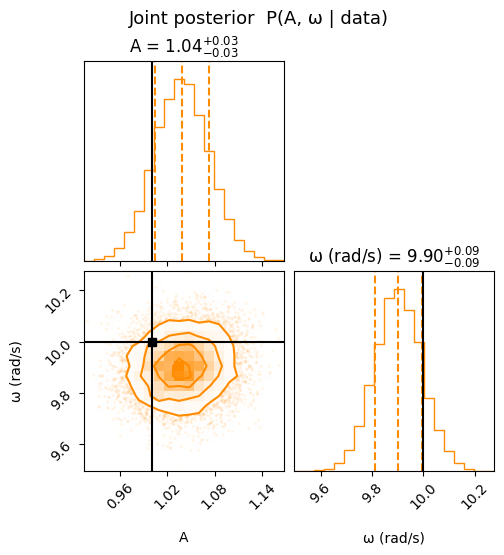


── Summary ─────────────────────────────────────────────
                  A        ω
True          1.000   10.000
SBI/NPE       1.038    9.902
n_bins=100  |  σ(A)=0.069  σ(ω)=0.182


100%|██████████| 10000/10000 [00:00<00:00, 66922.66it/s]


 Neural network successfully converged after 280 epochs.

Drawing 10000 posterior samples: 100%|██████████| 10000/10000 [00:00<00:00, 396152.48it/s]



Plotting …


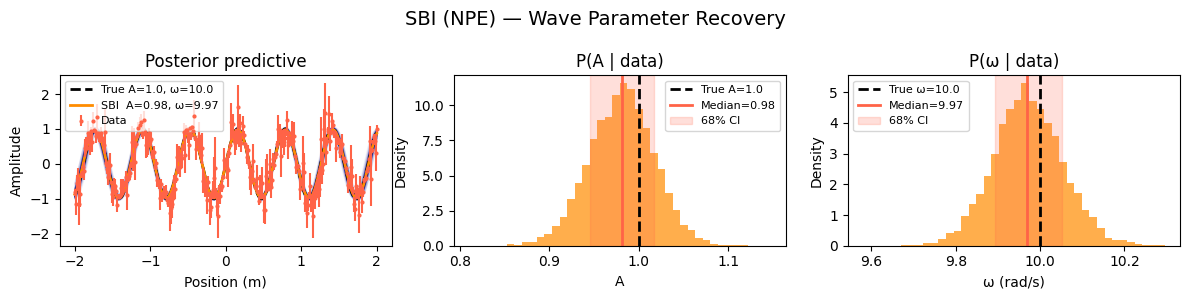

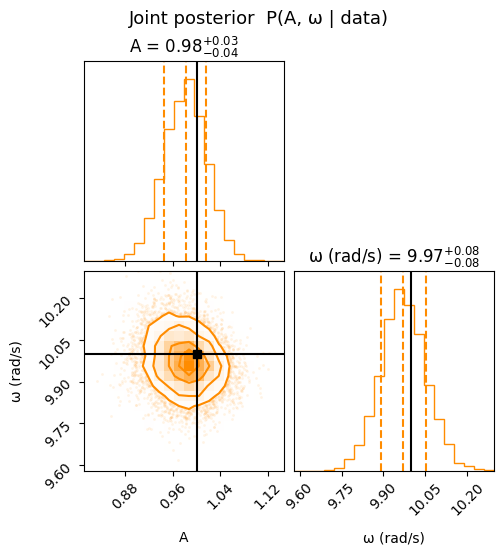


── Summary ─────────────────────────────────────────────
                  A        ω
True          1.000   10.000
SBI/NPE       0.982    9.970
n_bins= 50  |  σ(A)=0.071  σ(ω)=0.159


100%|██████████| 10000/10000 [00:00<00:00, 66996.31it/s]


 Neural network successfully converged after 215 epochs.

Drawing 10000 posterior samples: 100%|██████████| 10000/10000 [00:00<00:00, 363335.09it/s]



Plotting …


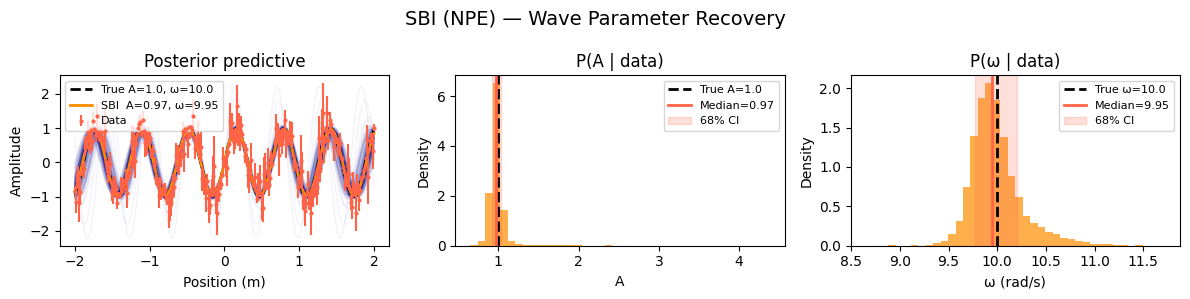

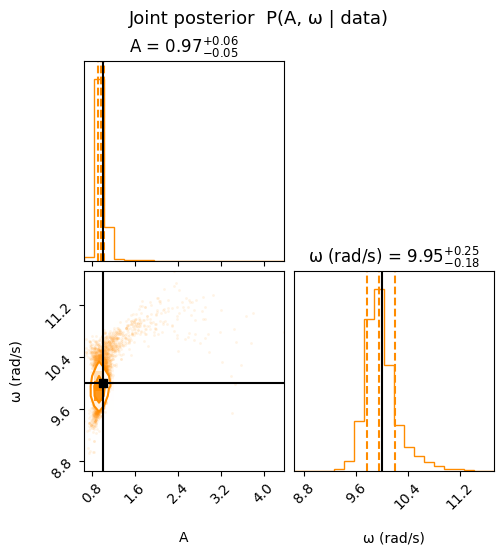


── Summary ─────────────────────────────────────────────
                  A        ω
True          1.000   10.000
SBI/NPE       0.972    9.948
n_bins= 25  |  σ(A)=0.110  σ(ω)=0.432


100%|██████████| 10000/10000 [00:00<00:00, 65172.46it/s]


 Neural network successfully converged after 372 epochs.

Drawing 10000 posterior samples: 10135it [00:00, 338624.85it/s]           



Plotting …


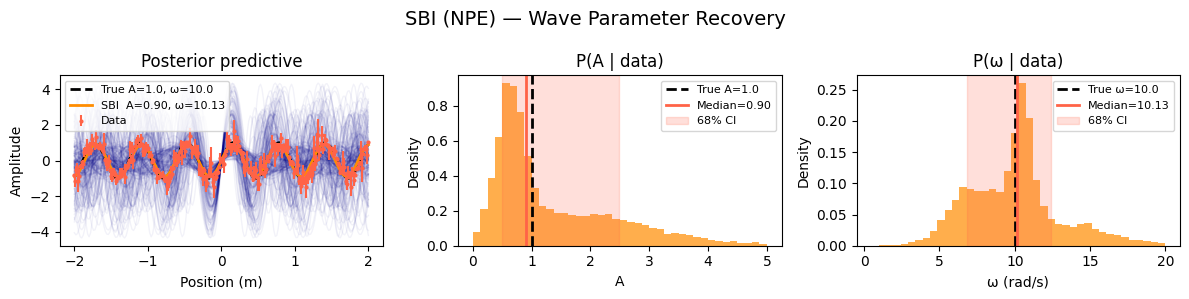

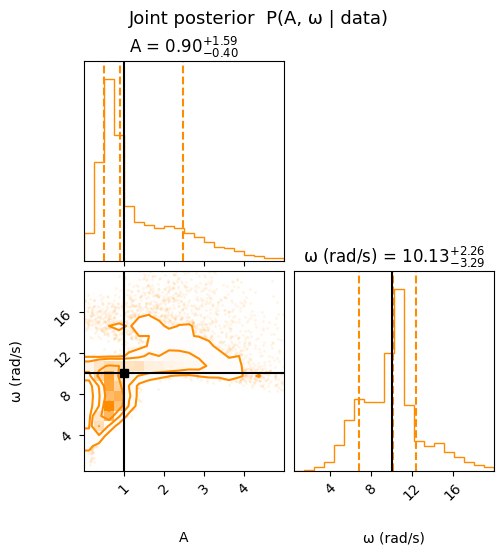


── Summary ─────────────────────────────────────────────
                  A        ω
True          1.000   10.000
SBI/NPE       0.899   10.130
n_bins=  5  |  σ(A)=1.985  σ(ω)=5.551


In [31]:
results = {}
for n_bins in [100, 50, 25, 5]:
    study = WaveSBI(n_points=300, n_simulations=10000,
                    noise_std=0.3, true_A = 1.0, true_omega=10.0, seed = 42, n_posterior=10000, nbins=n_bins)
    study.run_sbi(verbose=False)
    study.plot_comparison(figsize=(12, 3))

    A_width = np.diff(np.percentile(study.sbi_samples_np[:, 0], [16, 84]))[0]
    w_width = np.diff(np.percentile(study.sbi_samples_np[:, 1], [16, 84]))[0]
    results[n_bins] = {"A_width": A_width, "omega_width": w_width}
    print(f"n_bins={n_bins:3d}  |  σ(A)={A_width:.3f}  σ(ω)={w_width:.3f}")

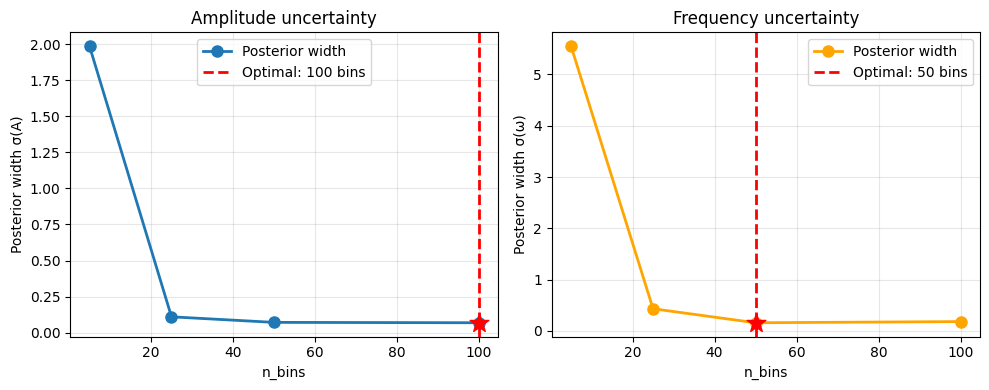

Optimal n_bins for A: 100  (width = 0.0688)
Optimal n_bins for ω: 50  (width = 0.1592)


In [ ]:
n_bins_list = sorted(results.keys())
A_widths = [results[nb]["A_width"] for nb in n_bins_list]
w_widths = [results[nb]["omega_width"] for nb in n_bins_list]

# Find optimal bins (minimum uncertainty)
optimal_A_idx = np.argmin(A_widths)
optimal_omega_idx = np.argmin(w_widths)
optimal_A_bins = n_bins_list[optimal_A_idx]
optimal_omega_bins = n_bins_list[optimal_omega_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot A uncertainty
ax1.plot(n_bins_list, A_widths, 'o-', lw=2, markersize=8, label="Posterior width")
ax1.axvline(optimal_A_bins, color='red', lw=2, ls='--', label=f"Optimal: {optimal_A_bins} bins")
ax1.scatter([optimal_A_bins], [A_widths[optimal_A_idx]], color='red', s=200, marker='*', zorder=5)
ax1.set(xlabel="n_bins", ylabel="Posterior width σ(A)", title="Amplitude uncertainty")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot ω uncertainty
ax2.plot(n_bins_list, w_widths, 'o-', lw=2, markersize=8, color="orange", label="Posterior width")
ax2.axvline(optimal_omega_bins, color='red', lw=2, ls='--', label=f"Optimal: {optimal_omega_bins} bins")
ax2.scatter([optimal_omega_bins], [w_widths[optimal_omega_idx]], color='red', s=200, marker='*', zorder=5)
ax2.set(xlabel="n_bins", ylabel="Posterior width σ(ω)", title="Frequency uncertainty")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Optimal n_bins for A: {optimal_A_bins}  (width = {A_widths[optimal_A_idx]:.4f})")
print(f"Optimal n_bins for ω: {optimal_omega_bins}  (width = {w_widths[optimal_omega_idx]:.4f})")
# I think it makes sense that you need less bins to infer omega because the noise over the data points affect
# the amplitude more. The frequency is largly uncorelated (?) with the noise because